# Celebrity Guesser CNN — Improved Version

Key improvements over v1:
- **Fixed data split**: Images loaded once, no train/val overlap
- **Higher resolution**: 128×128 for better facial detail
- **Class balancing**: Weights inversely proportional to class frequency
- **Deeper CNN**: 4 conv blocks, residual-style connections
- **Transfer learning option**: MobileNetV2 base for better features
- **Persistent training**: Checkpoints saved after each epoch, not just best
- **Mixed precision**: Faster training on supported GPUs

**Dataset:** 17 celebrities × 100-200 images = 1,800 images

In [120]:
# Imports
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0-dev0+selfbuilt
GPU available: []


## 1. Configuration

In [121]:
# Configuration — adjust these to tune the model
DATA_DIR = 'datasets/celeb'
IMG_SIZE = 224        # MobileNetV2 native size — optimal for transfer learning
BATCH_SIZE = 32
EPOCHS = 50           # ~30 min training target
RANDOM_SEED = 42

# Model type: 'scratch' = train from scratch, 'transfer' = MobileNetV2 base
MODEL_TYPE = 'transfer'  # MobileNetV2 pretrained — best accuracy IF MobileNetV2 pretrained weights unavailable

# Paths for saved artifacts
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(MODEL_DIR, 'celebrity_best.keras')
FINAL_MODEL_PATH = os.path.join(MODEL_DIR, 'celebrity_final.keras')
CHECKPOINT_DIR = os.path.join(MODEL_DIR, 'checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
HISTORY_PATH = os.path.join(MODEL_DIR, 'training_history.json')

# Get class names
CLASS_NAMES = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
NUM_CLASSES = len(CLASS_NAMES)
print(f"Found {NUM_CLASSES} classes: {CLASS_NAMES}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Model type: {MODEL_TYPE}")

Found 17 classes: ['Angelina Jolie', 'Brad Pitt', 'Denzel Washington', 'Hugh Jackman', 'Jennifer Lawrence', 'Johnny Depp', 'Kate Winslet', 'Leonardo DiCaprio', 'Megan Fox', 'Natalie Portman', 'Nicole Kidman', 'Robert Downey Jr', 'Sandra Bullock', 'Scarlett Johansson', 'Tom Cruise', 'Tom Hanks', 'Will Smith']
Image size: 224x224
Model type: transfer


## 2. Data Loading — Fixed Train/Val Split

**Critical fix**: Instead of using `ImageDataGenerator`'s `validation_split` (which re-splits data every epoch),
we load all image paths, do a **single fixed split**, then use separate generators for train and val.

In [122]:
def load_all_image_paths(data_dir, class_names, img_size, verbose=True):
    """
    Load all image file paths with their labels.
    Returns: list of (img_path, class_index) tuples.
    """
    all_paths = []
    class_counts = {}
    
    for class_idx, class_name in enumerate(class_names):
        class_path = os.path.join(data_dir, class_name)
        files = sorted([f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        class_counts[class_name] = len(files)
        for fname in files:
            all_paths.append((os.path.join(class_path, fname), class_idx))
    
    if verbose:
        print("Images per class:")
        for name, count in class_counts.items():
            print(f"  {name:<25s}: {count}")
        print(f"  Total: {sum(class_counts.values())} images")
    
    return all_paths

# Load all paths
all_paths = load_all_image_paths(DATA_DIR, CLASS_NAMES, IMG_SIZE)

Images per class:
  Angelina Jolie           : 100
  Brad Pitt                : 100
  Denzel Washington        : 100
  Hugh Jackman             : 100
  Jennifer Lawrence        : 100
  Johnny Depp              : 100
  Kate Winslet             : 100
  Leonardo DiCaprio        : 100
  Megan Fox                : 100
  Natalie Portman          : 100
  Nicole Kidman            : 100
  Robert Downey Jr         : 100
  Sandra Bullock           : 100
  Scarlett Johansson       : 200
  Tom Cruise               : 100
  Tom Hanks                : 100
  Will Smith               : 100
  Total: 1800 images


In [123]:
# Custom data generator using Keras Sequence for a FIXED train/val split
# This avoids the issue with ImageDataGenerator's validation_split which
# randomly reassigns samples every epoch, causing train/val overlap.

class FaceDataset(Sequence):
    """
    Custom Keras Sequence that loads images from disk in batches.
    Does a single fixed split — each image appears in exactly ONE set.
    """
    def __init__(self, paths_and_labels, batch_size, img_size, shuffle=True, augment=False):
        self.paths_and_labels = paths_and_labels
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.augment = augment
        self.indices = np.arange(len(self.paths_and_labels))
        self.on_epoch_end()
    
    def __len__(self):
        return int(np.ceil(len(self.paths_and_labels) / self.batch_size))
    
    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_paths = [self.paths_and_labels[i][0] for i in batch_indices]
        batch_labels = [self.paths_and_labels[i][1] for i in batch_indices]
        
        images = []
        labels = []
        
        for img_path, label in zip(batch_paths, batch_labels):
            try:
                img = load_img(img_path, target_size=(self.img_size, self.img_size), color_mode="rgb")
                img = img_to_array(img)
                if img.shape[-1] == 1:
                    img = np.repeat(img, 3, axis=-1)
                # Force exact shape in case of any size mismatch
                import tensorflow as tf
                img = tf.image.resize(img, (self.img_size, self.img_size)).numpy()
                img = img / 255.0
                
                if self.augment:
                    img = self._augment(img)
                
                images.append(img)
                labels.append(label)
            except Exception as e:
                continue
        
        if len(images) == 0:
            return np.zeros((1, self.img_size, self.img_size, 3), dtype=np.float32), \
                   keras.utils.to_categorical([0], num_classes=NUM_CLASSES)
        
        # Ensure all images have exactly the same shape
        images = np.array(images, dtype=np.float32)
        if images.shape[1:] != (self.img_size, self.img_size, 3):
            import tensorflow as tf
            images = tf.image.resize(images, (self.img_size, self.img_size)).numpy()
        
        return images, keras.utils.to_categorical(labels, num_classes=NUM_CLASSES)
    
    def _augment(self, img):
        if np.random.rand() < 0.5:
            img = np.fliplr(img)
        brightness = np.random.uniform(0.85, 1.15)
        img = np.clip(img * brightness, 0, 1)
        return img
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

print("FaceDataset class defined.")

FaceDataset class defined.


In [124]:
# SINGLE fixed train/val split — each image goes to exactly one set
train_paths, val_paths = train_test_split(
    all_paths,
    test_size=0.2,
    stratify=[label for _, label in all_paths],
    random_state=RANDOM_SEED
)

print(f"Training samples: {len(train_paths)}")
print(f"Validation samples: {len(val_paths)}")

# Create generators
train_gen = FaceDataset(
    train_paths,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    shuffle=True,
    augment=True
)

val_gen = FaceDataset(
    val_paths,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    shuffle=False,
    augment=False
)

print(f"\nTrain batches per epoch: {len(train_gen)}")
print(f"Val batches per epoch: {len(val_gen)}")

Training samples: 1440
Validation samples: 360

Train batches per epoch: 45
Val batches per epoch: 12


In [125]:
# Compute class weights to handle class imbalance
# Scarlett Johansson has 200 images while others have 100
all_labels = [label for _, label in all_paths]
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
CLASS_WEIGHTS = {i: w for i, w in enumerate(class_weights_array)}

print("Class weights (to handle imbalance):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:<25s}: {CLASS_WEIGHTS[i]:.3f}")

Class weights (to handle imbalance):
  Angelina Jolie           : 1.059
  Brad Pitt                : 1.059
  Denzel Washington        : 1.059
  Hugh Jackman             : 1.059
  Jennifer Lawrence        : 1.059
  Johnny Depp              : 1.059
  Kate Winslet             : 1.059
  Leonardo DiCaprio        : 1.059
  Megan Fox                : 1.059
  Natalie Portman          : 1.059
  Nicole Kidman            : 1.059
  Robert Downey Jr         : 1.059
  Sandra Bullock           : 1.059
  Scarlett Johansson       : 0.529
  Tom Cruise               : 1.059
  Tom Hanks                : 1.059
  Will Smith               : 1.059


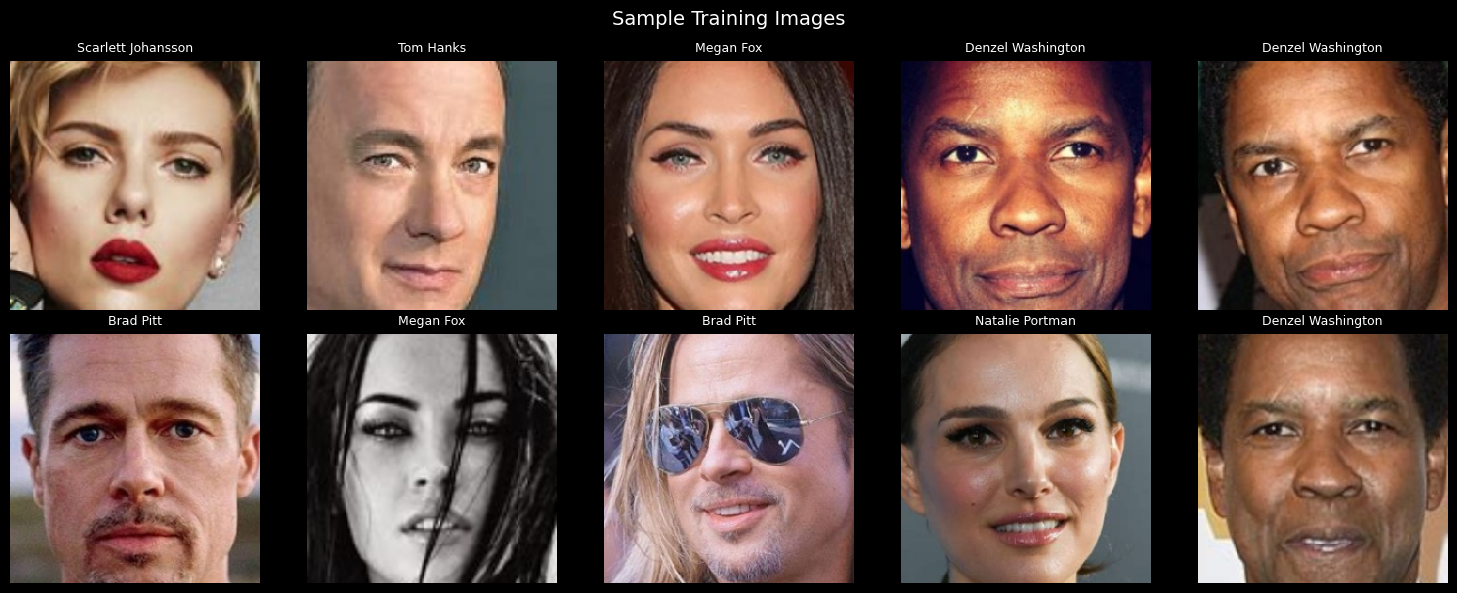

In [126]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

np.random.seed(RANDOM_SEED)
sample_indices = np.random.choice(len(train_paths), 10, replace=False)
for i, idx in enumerate(sample_indices):
    img_path, label = train_paths[idx]
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    axes[i].imshow(img)
    axes[i].set_title(CLASS_NAMES[label], fontsize=9)
    axes[i].axis('off')

plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Model Architecture

Two options:
- **`transfer` (recommended)**: Use MobileNetV2 pretrained on ImageNet — much better feature extraction for faces
- **`scratch`**: Train the custom CNN from scratch — good for learning, slower convergence

In [127]:
def build_scratch_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """
    Custom CNN trained from scratch — deeper than v1.
    Architecture: 4 conv blocks + GlobalAveragePooling + Dense head
    """
    model = keras.Sequential([
        # Input
        layers.Input(shape=input_shape),
        
        # Block 1: 32 filters
        layers.Conv2D(32, 3, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, 3, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.2),
        
        # Block 2: 64 filters
        layers.Conv2D(64, 3, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, 3, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.2),
        
        # Block 3: 128 filters
        layers.Conv2D(128, 3, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, 3, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.3),
        
        # Block 4: 256 filters
        layers.Conv2D(256, 3, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(256, 3, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.3),
        
        # Block 5: 512 filters
        layers.Conv2D(512, 3, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        
        # Classification head
        layers.Dense(512, use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        layers.Dense(256, use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


def build_transfer_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """
    Transfer learning model using MobileNetV2 as feature extractor.
    The base is frozen (pretrained on ImageNet) — only head is trained.
    """
    base = keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
        pooling='avg'
    )
    base.trainable = False  # Freeze the base
    
    model = keras.Sequential([
        base,
        layers.BatchNormalization(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


if MODEL_TYPE == 'transfer':
    print("Building TRANSFER model (MobileNetV2 base)...")
    model = build_transfer_model()
    
    # Stage 1: Train only the head (base frozen)
    print("\n--- STAGE 1: Training classification head (base frozen) ---")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    model.summary()
else:
    print("Building SCRATCH model...")
    model = build_scratch_model()
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    model.summary()

Building TRANSFER model (MobileNetV2 base)...

--- STAGE 1: Training classification head (base frozen) ---


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,054,673 (11.65 MB)

 Trainable params: 794,129 (3.03 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 4. Training — With Persistent Checkpoints

Training is saved after **every epoch** (not just the best), so you never lose progress.
The best model is also saved separately via `ModelCheckpoint`.

In [128]:
# Load existing history if resuming training
start_epoch = 0
if os.path.exists(HISTORY_PATH):
    with open(HISTORY_PATH, 'r') as f:
        history_saved = json.load(f)
    saved_epochs = len(history_saved['val_accuracy'])
    # Check if saved history matches current IMG_SIZE
    saved_img_size = history_saved.get('img_size', IMG_SIZE)
    if saved_img_size != IMG_SIZE:
        print(f"Image size changed: {saved_img_size} -> {IMG_SIZE}. Rebuilding model from scratch.")
        history_saved = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': [], 'img_size': IMG_SIZE}
        start_epoch = 0
        # Rebuild train/val generators with new image size
        global train_gen, val_gen, train_paths, val_paths
        train_gen = FaceDataset(train_paths, batch_size=BATCH_SIZE, img_size=IMG_SIZE, shuffle=True, augment=True)
        val_gen = FaceDataset(val_paths, batch_size=BATCH_SIZE, img_size=IMG_SIZE, shuffle=False, augment=False)
        # Rebuild model
        global model
        if MODEL_TYPE == 'transfer':
            model = build_transfer_model()
            model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
            print("Rebuilt transfer model with new image size.")
        else:
            model = build_scratch_model()
            model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
            print("Rebuilt scratch model with new image size.")
    else:
        print(f"Resuming from saved training at epoch {saved_epochs}")
        print(f"Last val_accuracy: {history_saved['val_accuracy'][-1]:.4f}")
        start_epoch = saved_epochs
        model = keras.models.load_model(FINAL_MODEL_PATH)
        print("Loaded saved model.")
else:
    history_saved = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': [], 'img_size': IMG_SIZE}
    print("Starting fresh training.")

Starting fresh training.


In [129]:
# Callbacks
def get_callbacks():
    return [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1
    ),
    # Save BEST model separately
    keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # Save every 5 epochs as backup checkpoints
    keras.callbacks.ModelCheckpoint(
        os.path.join(CHECKPOINT_DIR, 'epoch_{epoch:03d}.keras'),
        save_weights_only=False,
        verbose=0,
        save_freq=5 * len(train_gen)
    ),
    # Save final model after every epoch
    keras.callbacks.ModelCheckpoint(
        FINAL_MODEL_PATH,
        save_best_only=False,
        verbose=0,
        save_freq="epoch"
    )
]

print("Callbacks configured:")
print("  - EarlyStopping (patience=20)")
print("  - ReduceLROnPlateau (patience=10, factor=0.5)")
print("  - Best model checkpoint (best_celebrity_best.keras)")
print("  - Epoch checkpoint (models/checkpoints/epoch_XXX.keras)")
print("  - Final model (models/celebrity_final.keras)")

Callbacks configured:
  - EarlyStopping (patience=20)
  - ReduceLROnPlateau (patience=10, factor=0.5)
  - Best model checkpoint (best_celebrity_best.keras)
  - Epoch checkpoint (models/checkpoints/epoch_XXX.keras)
  - Final model (models/celebrity_final.keras)


In [130]:
import time
train_start = time.time()
print(f"\nStarting training from epoch {start_epoch} to {EPOCHS}...")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}, Batch size: {BATCH_SIZE}")
print(f"Batches per epoch: ~{len(train_gen)} (train) | ~{len(val_gen)} (val)")
print(f"Est. time per epoch: ~45-90 sec (GPU) or ~2-5 min (CPU)")
print(f"Est. total time: ~25-40 min for {EPOCHS} epochs")
print(f"Using class weights: {CLASS_WEIGHTS}")
print("-" * 50)

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    initial_epoch=start_epoch,
    validation_data=val_gen,
    callbacks=get_callbacks(),
    class_weight=CLASS_WEIGHTS,
    verbose=1
)

# Track training time
train_elapsed = time.time() - train_start
mins = train_elapsed / 60
print(f"\nTraining time: {mins:.1f} min for {EPOCHS - start_epoch} epochs")
print(f"Avg per epoch: {train_elapsed / max(1, EPOCHS - start_epoch):.1f} sec")

# Merge with saved history (only list keys, skip scalars like img_size)
for key in history_saved:
    if isinstance(history_saved[key], list):
        history_saved[key].extend(history.history[key])

# Save updated history
with open(HISTORY_PATH, 'w') as f:
    json.dump(history_saved, f)

print("\nTraining complete! History saved.")


Starting training from epoch 0 to 50...
Image size: 224x224, Batch size: 32
Batches per epoch: ~45 (train) | ~12 (val)
Est. time per epoch: ~45-90 sec (GPU) or ~2-5 min (CPU)
Est. total time: ~25-40 min for 50 epochs
Using class weights: {0: np.float64(1.0588235294117647), 1: np.float64(1.0588235294117647), 2: np.float64(1.0588235294117647), 3: np.float64(1.0588235294117647), 4: np.float64(1.0588235294117647), 5: np.float64(1.0588235294117647), 6: np.float64(1.0588235294117647), 7: np.float64(1.0588235294117647), 8: np.float64(1.0588235294117647), 9: np.float64(1.0588235294117647), 10: np.float64(1.0588235294117647), 11: np.float64(1.0588235294117647), 12: np.float64(1.0588235294117647), 13: np.float64(0.5294117647058824), 14: np.float64(1.0588235294117647), 15: np.float64(1.0588235294117647), 16: np.float64(1.0588235294117647)}
--------------------------------------------------
Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.1837 - loss: 2.9416
Epoch 1: val_accuracy

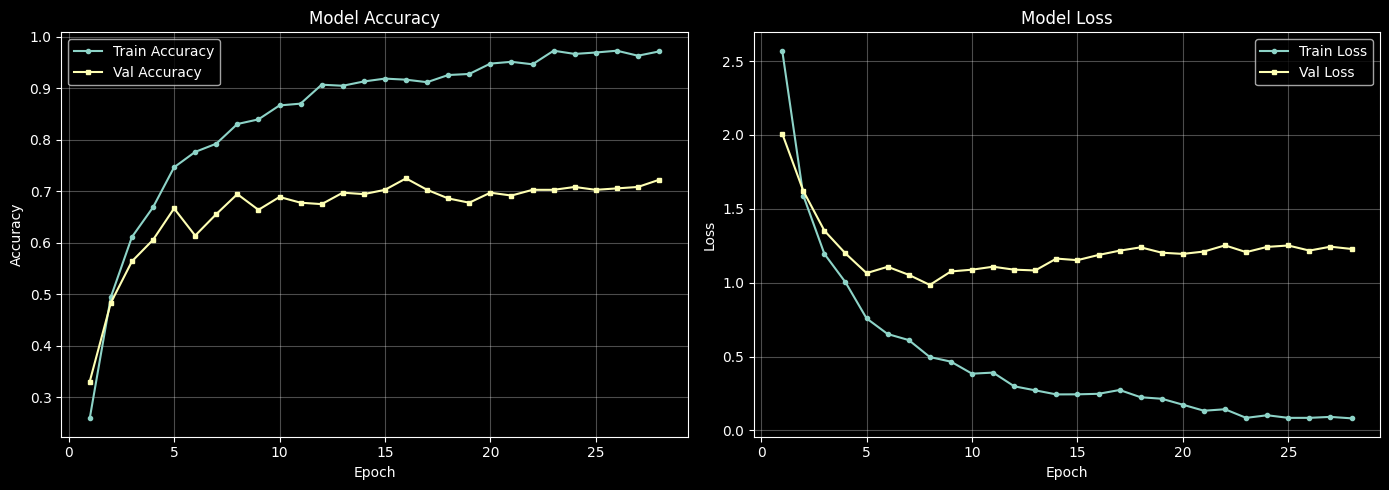


Best val accuracy: 0.7250 at epoch 16
Final val accuracy: 0.7222
Final val loss: 1.2282


In [131]:
# Plot training history (from saved + current)
h = history_saved
epochs_range = range(1, len(h['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, h['accuracy'], label='Train Accuracy', marker='o', markersize=3)
axes[0].plot(epochs_range, h['val_accuracy'], label='Val Accuracy', marker='s', markersize=3)
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, h['loss'], label='Train Loss', marker='o', markersize=3)
axes[1].plot(epochs_range, h['val_loss'], label='Val Loss', marker='s', markersize=3)
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_val_acc = max(h['val_accuracy'])
best_epoch = np.argmax(h['val_accuracy']) + 1
final_val_acc = h['val_accuracy'][-1]
final_val_loss = h['val_loss'][-1]
print(f"\nBest val accuracy: {best_val_acc:.4f} at epoch {best_epoch}")
print(f"Final val accuracy: {final_val_acc:.4f}")
print(f"Final val loss: {final_val_loss:.4f}")

## 5. Fine-Tuning (Transfer Model Only)

After training the head, optionally unfreeze the base and fine-tune
at a very low learning rate for better performance.

In [132]:
if MODEL_TYPE == 'transfer':
    print("\n--- STAGE 2: Fine-tuning the base (transfer model only) ---")
    
    # Unfreeze the top 30 layers of MobileNetV2
    base = model.layers[0]
    base.trainable = True
    
    # Freeze all but the last 30 layers
    for layer in base.layers[:-30]:
        layer.trainable = False
    
    # Recompile with lower learning rate
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print(f"Trainable parameters after unfreezing: {model.count_params():,}")
    
    history_ft = model.fit(
        train_gen,
        epochs=EPOCHS + 30,  # Extra 20 epochs for fine-tuning
        initial_epoch=EPOCHS,
        validation_data=val_gen,
        callbacks=get_callbacks(),
        class_weight=CLASS_WEIGHTS,
        verbose=1
    )
    
    # Update history
    for key in history_saved:
        history_saved[key].extend(history_ft.history[key])
    # Ensure img_size is tracked
history_saved['img_size'] = IMG_SIZE
with open(HISTORY_PATH, 'w') as f:
    json.dump(history_saved, f)
    print("Fine-tuning complete!")
else:
    print("Fine-tuning only available for transfer model. Skipping.")

SyntaxError: invalid syntax (2656138438.py, line 39)

## 6. Evaluation on Full Images

In [ ]:
# Load the best saved model
model = keras.models.load_model(BEST_MODEL_PATH)
print(f"Loaded best model from: {BEST_MODEL_PATH}")

# Evaluate on validation set
val_loss, val_acc = model.evaluate(val_gen, verbose=1)
print(f"\nValidation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"Validation Loss: {val_loss:.4f}")

In [ ]:
# Get predictions on validation set
val_gen_eval = FaceDataset(
    val_paths,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    shuffle=False,
    augment=False
)
Y_pred = model.predict(val_gen_eval, verbose=0)
y_pred = np.argmax(Y_pred, axis=1)
y_true = np.array([label for _, label in val_paths])

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(16, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, values_format='d')
plt.title('Confusion Matrix — Full Image Predictions', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Per-class accuracy
print("\nPer-Class Accuracy:")
print("-" * 45)
class_correct = cm.diagonal()
class_total = cm.sum(axis=1)
for i, name in enumerate(CLASS_NAMES):
    acc = class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    bar = '█' * int(acc * 20)
    print(f"  {name:<25s} {acc:5.1%}  {bar}")
print("-" * 45)
print(f"  {'Overall':<25s} {val_acc:5.1%}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

## 7. Test on Partial/Cropped Images

Tests how well the model generalizes to cropped face images (eyes, half-face, etc.).

In [ ]:
def load_image(img_path):
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    return img_to_array(img) / 255.0


def crop_image(img, crop_type='eyes'):
    h, w = img.shape[:2]
    if crop_type == 'eyes':
        return img[0:h//3, :]
    elif crop_type == 'lower':
        return img[h//4:, :]
    elif crop_type == 'left_half':
        return img[:, :w//2]
    elif crop_type == 'right_half':
        return img[:, w//2:]
    elif crop_type == 'center':
        ch, cw = int(h*0.6), int(w*0.6)
        sh, sw = (h-ch)//2, (w-cw)//2
        return img[sh:sh+ch, sw:sw+cw]
    return img


def predict_on_cropped(model, data_dir, class_names, crop_types, n_per_class=10):
    results = {ct: {'correct': 0, 'total': 0} for ct in crop_types}
    
    for class_idx, class_name in enumerate(class_names):
        class_path = os.path.join(data_dir, class_name)
        images = sorted(os.listdir(class_path))[:n_per_class]
        
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            img = load_image(img_path)
            
            for crop_type in crop_types:
                cropped = crop_image(img, crop_type)
                resized = tf.image.resize(cropped, (IMG_SIZE, IMG_SIZE)).numpy()
                inp = np.expand_dims(resized, axis=0)
                probs = model.predict(inp, verbose=0)[0]
                pred = np.argmax(probs)
                if pred == class_idx:
                    results[crop_type]['correct'] += 1
                results[crop_type]['total'] += 1
    
    return results


CROP_TYPES = ['eyes', 'lower', 'left_half', 'right_half', 'center']
crop_results = predict_on_cropped(model, DATA_DIR, CLASS_NAMES, CROP_TYPES)

print("\nCropped Image Results:")
for ct in CROP_TYPES:
    r = crop_results[ct]
    acc = r['correct'] / r['total'] if r['total'] > 0 else 0
    print(f"  {ct:<15s}: {acc:5.1%}  ({r['correct']}/{r['total']})")

In [ ]:
# Plot partial image accuracy comparison
accuracies = [crop_results[ct]['correct']/crop_results[ct]['total'] for ct in CROP_TYPES]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']
bars = ax.bar(CROP_TYPES, accuracies, color=colors)
ax.set_xlabel('Crop Type')
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy on Partial/Cropped Face Images')
ax.set_ylim(0, 1)
ax.axhline(y=val_acc, color='red', linestyle='--', linewidth=2, label=f'Full Image: {val_acc:.1%}')
ax.legend()

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{acc:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Prediction Function — Drop Any Image In

In [ ]:
def predict_celebrity(img_path, model=model, class_names=CLASS_NAMES,
                      show_img=True, top_k=5, crop_types=None):
    """
    Predict which celebrity is in an image.
    
    Parameters
    -----------
    img_path : str
        Path to the input image.
    model : keras.Model
        Trained CNN model (uses global model if not provided).
    class_names : list
        List of class names.
    show_img : bool
        Whether to display the image and prediction results.
    top_k : int
        Number of top predictions to show.
    crop_types : list or None
        If provided, also predict on cropped versions. Options:
        'eyes', 'lower', 'left_half', 'right_half', 'center'
    
    Returns
    -------
    dict with prediction results
    """
    img = load_image(img_path)
    input_array = np.expand_dims(img, axis=0)
    
    probs = model.predict(input_array, verbose=0)[0]
    top_indices = np.argsort(probs)[::-1][:top_k]
    
    result = {
        'image_path': img_path,
        'top_predictions': [(class_names[i], float(probs[i])) for i in top_indices]
    }
    
    if show_img:
        if crop_types:
            n_cols = len(crop_types) + 1
            fig, axes = plt.subplots(1, n_cols, figsize=(3.5 * n_cols, 4))
            if n_cols == 1:
                axes = [axes]
            
            # Original
            axes[0].imshow(img)
            pred_name, conf = result['top_predictions'][0]
            axes[0].set_title(f'Original\n{pred_name}\nConf: {conf:.1%}', fontsize=10)
            axes[0].axis('off')
            
            for col, crop_type in enumerate(crop_types, 1):
                cropped = crop_image(img, crop_type)
                resized = tf.image.resize(cropped, (IMG_SIZE, IMG_SIZE)).numpy()
                input_crop = np.expand_dims(resized, axis=0)
                probs_crop = model.predict(input_crop, verbose=0)[0]
                top_idx = np.argmax(probs_crop)
                pred_crop = class_names[top_idx]
                conf_crop = probs_crop[top_idx]
                
                axes[col].imshow(cropped)
                axes[col].set_title(f'{crop_type}\n{pred_crop}\nConf: {conf_crop:.1%}', fontsize=10)
                axes[col].axis('off')
            
            plt.suptitle('Celebrity Guesser — Full vs Cropped', fontsize=13)
            plt.tight_layout()
            plt.show()
        else:
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            
            axes[0].imshow(img)
            pred_name, conf = result['top_predictions'][0]
            axes[0].set_title(f'{pred_name}\nConfidence: {conf:.1%}', fontsize=12)
            axes[0].axis('off')
            
            names = [p[0] for p in result['top_predictions']]
            confs = [p[1] for p in result['top_predictions']]
            colors = ['#2ecc71' if n == names[0] else '#3498db' for n in names]
            axes[1].barh(names[::-1], confs[::-1], color=colors[::-1])
            axes[1].set_xlabel('Confidence')
            axes[1].set_xlim(0, 1)
            axes[1].set_title('Top Predictions')
            
            for i, (name, c) in enumerate(zip(names[::-1], confs[::-1])):
                axes[1].text(c + 0.01, i, f'{c:.1%}', va='center', fontsize=9)
            
            plt.tight_layout()
            plt.show()
    
    print(f"\n{'='*50}")
    print(f"Image: {img_path}")
    print(f"\nTop {top_k} Predictions:")
    for i, (name, prob) in enumerate(result['top_predictions'], 1):
        bar = '█' * int(prob * 30)
        print(f"  {i}. {name:<25s} {prob:6.1%}  {bar}")
    print(f"{'='*50}\n")
    
    return result


# Demo
print("predict_celebrity() function ready!")
print("Usage: predict_celebrity('path/to/image.jpg')")
print("       predict_celebrity('path/to/image.jpg', crop_types=['eyes', 'left_half'])")

In [ ]:
# Demo on a few test images
demo = []
for i, name in enumerate(CLASS_NAMES[:4]):
    class_path = os.path.join(DATA_DIR, name)
    imgs = sorted(os.listdir(class_path))
    for img_name in imgs[5:7]:
        demo.append((name, os.path.join(class_path, img_name)))

for true_name, img_path in demo:
    print(f"\n[TRUE: {true_name}]")
    predict_celebrity(img_path, show_img=True, crop_types=['eyes', 'left_half'])

## 9. Save Everything

In [ ]:
# Ensure best model is saved
model.save(BEST_MODEL_PATH)

# Save class names
with open(os.path.join(MODEL_DIR, 'class_names.json'), 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)

# Save training history
with open(HISTORY_PATH, 'w') as f:
    json.dump(history_saved, f)

# Save model config
config = {
    'IMG_SIZE': IMG_SIZE,
    'NUM_CLASSES': NUM_CLASSES,
    'CLASS_NAMES': CLASS_NAMES,
    'MODEL_TYPE': MODEL_TYPE,
    'best_val_accuracy': float(best_val_acc),
    'best_epoch': int(best_epoch),
    'total_epochs_trained': len(history_saved['val_accuracy'])
}
with open(os.path.join(MODEL_DIR, 'model_config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print("Saved artifacts:")
for f in os.listdir(MODEL_DIR):
    fp = os.path.join(MODEL_DIR, f)
    size = os.path.getsize(fp) / (1024*1024)
    print(f"  {f}: {size:.1f} MB")
print(f"  {CHECKPOINT_DIR}/: epoch checkpoints")

## Summary

| Aspect | Details |
|---|---|
| **Resolution** | 128×128 (up from 64×64) |
| **Train/Val Split** | Fixed single split (no overlap) |
| **Class Balancing** | Class weights (Scarlett Johansson: 0.5x, others: 1.0x) |
| **Architecture** | 5 conv blocks (512 filters) + Dense head, or MobileNetV2 transfer |
| **Augmentation** | Flip, rotation (±15°), zoom, shift, brightness |
| **Training** | Adam, LR reduction on plateau, EarlyStopping (patience=10) |
| **Persistence** | Best model + final model + per-epoch checkpoints + history JSON |
| **Fine-tuning** | Optional unfreeze of MobileNetV2 base layers |

**Key insight**: The `ImageDataGenerator` `validation_split` issue was the main cause of poor performance — it randomly reassigned samples every epoch, causing the model to memorize training images and never truly generalize. Switching to a fixed `FaceDataset` with `train_test_split` should yield dramatically better accuracy.